In [ ]:
from configPy import DirManager, EnvManager, Config
import pandas as pd
import matplotlib.pyplot as plt

file_dir = Config.get_dir_files()
planilhas = file_dir["planilhas"]

# arquivo de interesse

orcamento = planilhas.get_any("planilha_Dados - Orçamento.csv")


In [3]:
df = pd.read_csv(orcamento)

In [7]:
df.head()

,Centro de Responsabilidade,Cod centro,Nome conta 1º nível,Cod conta 1º nível,Nome conta 2º nível,Cod conta 2º nível,Nome conta 3º nível,Cod conta 3º nível,Ano,Mês,nº mês,Realizado
0,Mirante,10113,Despesa,1,Despesas Correntes,11,Pessoal e Encargos,111,2022,JANEIRO,1,278804.36
1,Mirante,10113,Despesa,1,Despesas Correntes,11,Ocupação e Utilidades,115,2022,JANEIRO,1,11159.69
2,Mirante,10113,Despesa,1,Despesas Correntes,11,Material de Consumo,114,2022,JANEIRO,1,20196.21
3,Mirante,10113,Despesa,1,Despesas Correntes,11,Transportes e Viagens,111,2022,JANEIRO,1,14646.09
4,Mirante,10113,Despesa,1,Despesas Correntes,11,Serviços de terceiros,117,2022,JANEIRO,1,33010.87


## Nível de receita e despesa por Centro de Custo

In [ ]:
# Identificar todos os centros
# Criar data frame filtrando as linhas com o centro desejado
# Incluir apenas os dados de interesse (Nome conta 1° nível, Realizado)

In [6]:
# valore únicos dos centros
centros = df['Centro de Responsabilidade'].unique()
centros

<StringArray>
['Mirante', 'Sol Leste', 'Vitória']
Length: 3, dtype: str

In [39]:
df_agrupamento = df.groupby(["Centro de Responsabilidade", "Nome conta 1º nível"])["Realizado"].sum().unstack().abs()
print(df_agrupamento)

Nome conta 1º nível            Despesa     Receita
Centro de Responsabilidade                        
Mirante                     6571299.17  8762190.58
Sol Leste                   1375208.01  7925520.62
Vitória                     8077648.37  7669373.69


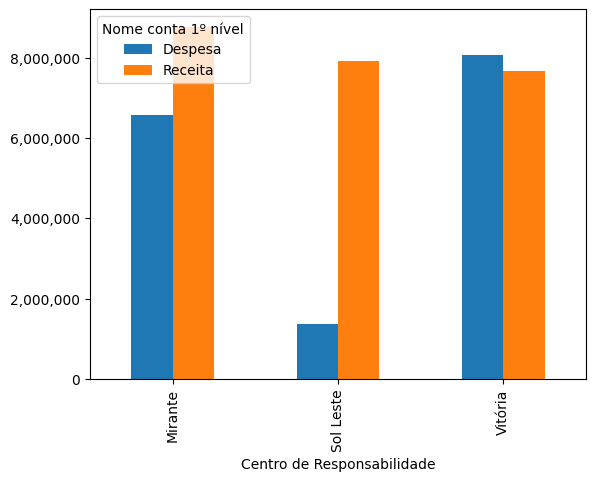

In [43]:
import matplotlib.ticker as ticker
ax = df_agrupamento.plot.bar()

ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.show()

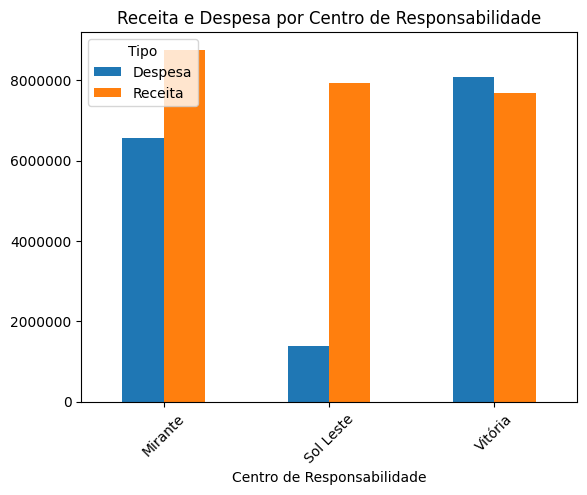

In [44]:
import matplotlib.pyplot as plt

df_agrupamento.plot.bar()

plt.title("Receita e Despesa por Centro de Responsabilidade")
plt.xlabel("Centro de Responsabilidade")

plt.ticklabel_format(style='plain', axis='y')

plt.xticks(rotation=45)
plt.legend(title="Tipo")

plt.show()

## Lucro por filial

In [45]:
lucro_por_filial = df_agrupamento["Receita"] - df_agrupamento["Despesa"]
lucro_por_filial

Centro de Responsabilidade
Mirante      2190891.41
Sol Leste    6550312.61
Vitória      -408274.68
dtype: float64

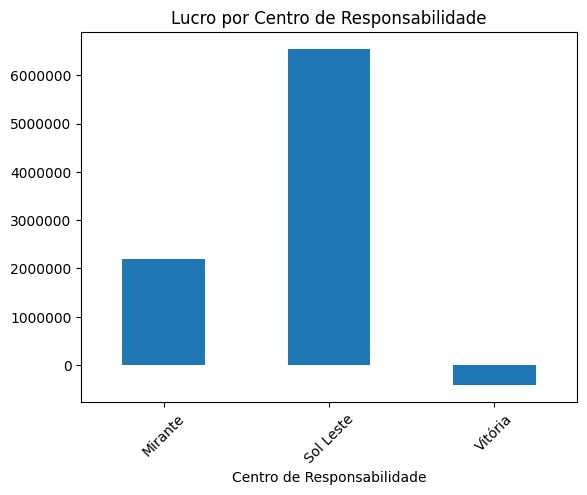

In [49]:
lucro_por_filial.plot.bar()

plt.title("Lucro por Centro de Responsabilidade")
plt.xlabel("Centro de Responsabilidade")


plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)

plt.show()

## Despesa por conta

In [53]:
df_de_despesa = df[df["Nome conta 1º nível"] == "Despesa"]
df_despesa_por_conta = df_de_despesa.groupby("Nome conta 3º nível")["Realizado"].sum()
df_despesa_por_conta

Nome conta 3º nível
Impostos e taxas          745327.89
Investimentos            3496171.89
Material de Consumo       594953.32
Ocupação e Utilidades     363427.55
Outras despesas           182365.68
Pessoal e Encargos       9297066.37
Serviços de terceiros     953086.94
Transportes e Viagens     391755.91
Name: Realizado, dtype: float64

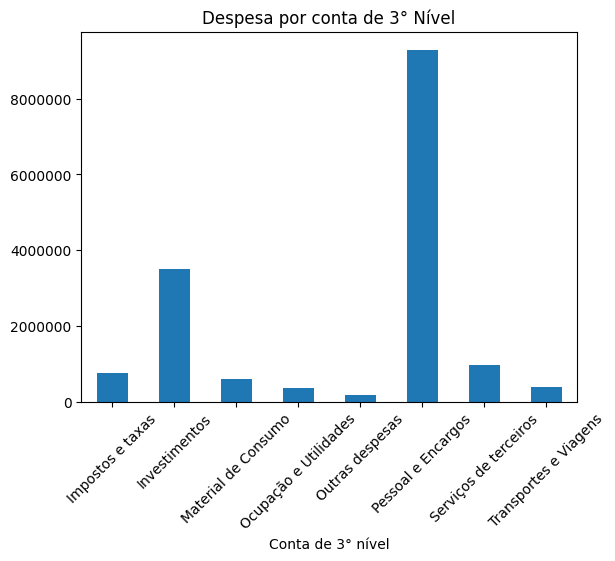

In [55]:
df_despesa_por_conta.plot.bar()

plt.title("Despesa por conta de 3° Nível")
plt.xlabel("Conta de 3° nível")


plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)

plt.show()

## Despesa e receita por conta 2° nível

In [59]:
df_receita_despesa_conta = df.groupby(["Nome conta 1º nível", "Nome conta 2º nível"])["Realizado"].sum().unstack()
df_receita_despesa_conta

Nome conta 2º nível,Despesas Correntes,Despesas de Capital,Receitas Correntes
Nome conta 1º nível,,,
Despesa,12527983.66,3496171.89,NaN
Receita,NaN,NaN,24357084.89


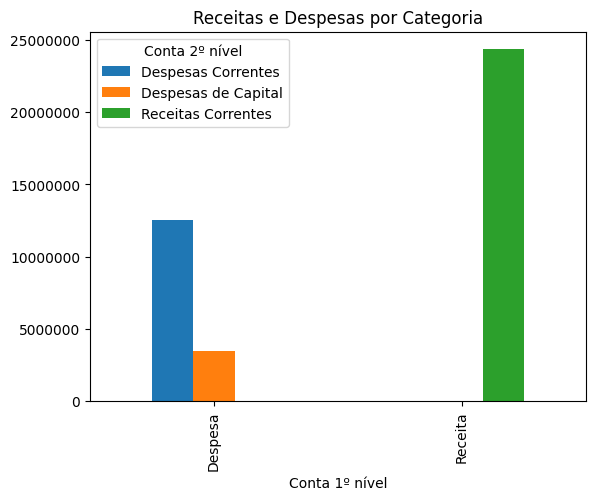

In [61]:
df_plot = df_receita_despesa_conta.fillna(0)

df_plot.plot.bar()

plt.title("Receitas e Despesas por Categoria")
plt.xlabel("Conta 1º nível")

plt.ticklabel_format(style='plain', axis='y')
plt.legend(title="Conta 2º nível")

plt.show()

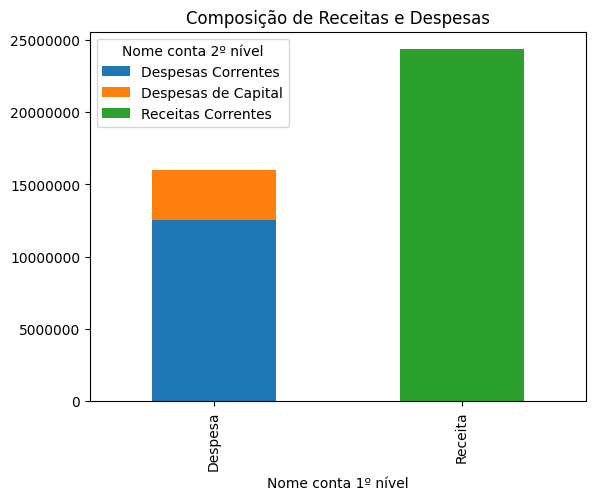

In [63]:
df_plot.plot.bar(stacked=True)

plt.title("Composição de Receitas e Despesas")
plt.ticklabel_format(style='plain', axis='y')

plt.show()

In [ ]:
orcamento = planilhas.get_any("planilha_Dados - Mercado.csv")